<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Case 4: Water Drive Reservoir (Tarek Ahmed, Example 11-5)
# Pot Aquifer Model: We = K * dP
# MBE: F/Eo = N + K * (dP/Eo)

Pi = 3500  # psia

data = pd.DataFrame({
    'P':  [3500, 3488, 3162, 2782],
    'F':  [0, 2.04e6, 8.77e6, 17.05e6],    # bbl
    'Eo': [0, 0.0548, 0.1540, 0.2820]       # bbl/STB
})
data

,P,F,Eo
0,3500,0.0,0.0000
1,3488,2040000.0,0.0548
2,3162,8770000.0,0.1540
3,2782,17050000.0,0.2820


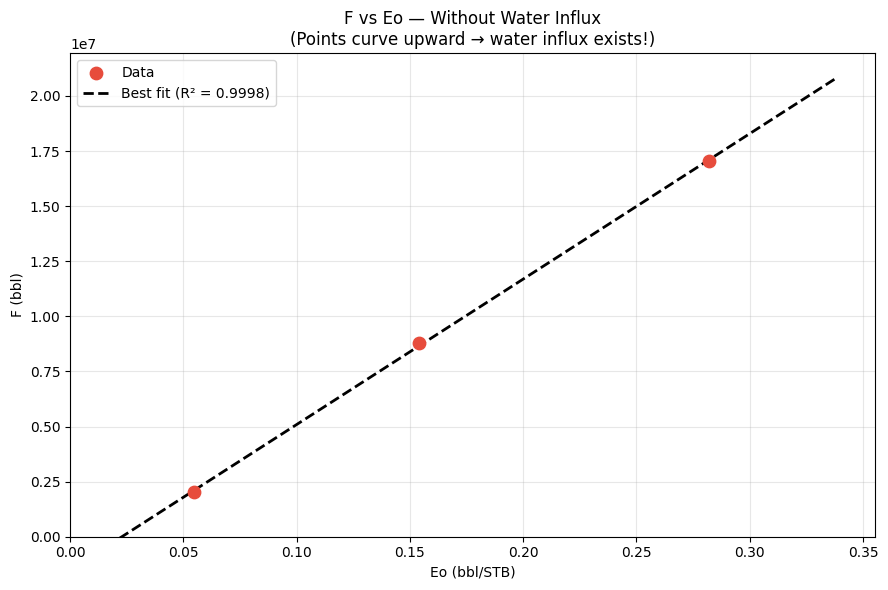

Points deviate upward from the straight line
→ This indicates unaccounted water influx pushing extra fluid out


In [ ]:
mask = data['F'] > 0
x1, y1 = data.loc[mask, 'Eo'].values, data.loc[mask, 'F'].values

sl1, ic1, r1, _, _ = linregress(x1, y1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x1, y1, c='#e74c3c', s=80, zorder=5, label='Data')
xl = np.linspace(0, x1.max() * 1.2, 100)
ax.plot(xl, sl1 * xl + ic1, 'k--', lw=2, label=f'Best fit (R² = {r1**2:.4f})')

ax.set_xlabel('Eo (bbl/STB)')
ax.set_ylabel('F (bbl)')
ax.set_title('F vs Eo — Without Water Influx\n(Points curve upward → water influx exists!)')
ax.legend()
ax.set_xlim(0); ax.set_ylim(0); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Points deviate upward from the straight line")
print("→ This indicates unaccounted water influx pushing extra fluid out")

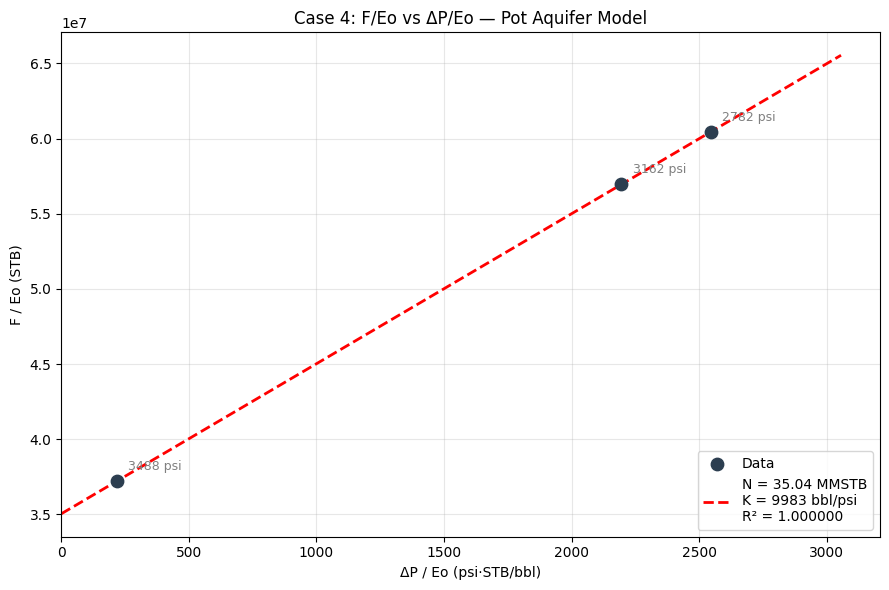

N (OOIP)          = 35.04 MMSTB
K (aquifer const) = 9983 bbl/psi
R²                = 1.000000


In [ ]:
dP = Pi - data['P']

data.loc[mask, 'dP']     = dP[mask]
data.loc[mask, 'F/Eo']   = data.loc[mask, 'F'] / data.loc[mask, 'Eo']
data.loc[mask, 'dP/Eo']  = dP[mask].values / data.loc[mask, 'Eo'].values

x = data.loc[mask, 'dP/Eo'].values
y = data.loc[mask, 'F/Eo'].values

slope, intercept, r, _, _ = linregress(x, y)
N = intercept                # STB
K = slope                    # bbl/psi (aquifer constant)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, c='#2c3e50', s=80, zorder=5, label='Data')

for xi, yi, pi in zip(x, y, data.loc[mask, 'P']):
    ax.annotate(f'{pi:.0f} psi', (xi, yi), textcoords="offset points",
                xytext=(8, 8), fontsize=9, color='gray')

xl = np.linspace(0, x.max() * 1.2, 100)
ax.plot(xl, slope * xl + intercept, 'r--', lw=2,
        label=f'N = {N/1e6:.2f} MMSTB\nK = {K:.0f} bbl/psi\nR² = {r**2:.6f}')

ax.set_xlabel('ΔP / Eo (psi·STB/bbl)')
ax.set_ylabel('F / Eo (STB)')
ax.set_title('Case 4: F/Eo vs ΔP/Eo — Pot Aquifer Model')
ax.legend(loc='lower right')
ax.set_xlim(0); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N (OOIP)          = {N/1e6:.2f} MMSTB")
print(f"K (aquifer const) = {K:.0f} bbl/psi")
print(f"R²                = {r**2:.6f}")

In [ ]:
data.loc[mask, 'We'] = K * dP[mask]

print("Water Influx (Pot Aquifer Model):")
print("-" * 45)
for _, row in data[mask].iterrows():
    print(f"  P = {row['P']:.0f} psi | ΔP = {row['dP']:.0f} psi | We = {row['We']/1e6:.2f} MM bbl")

# Verify: F should equal N*Eo + We
data.loc[mask, 'F_calc'] = N * data.loc[mask, 'Eo'] + data.loc[mask, 'We']

print(f"\nVerification (F_actual vs F_calculated):")
for _, row in data[mask].iterrows():
    err = (row['F_calc'] - row['F']) / row['F'] * 100
    print(f"  P = {row['P']:.0f} | F_actual = {row['F']/1e6:.2f}M | F_calc = {row['F_calc']/1e6:.2f}M | err = {err:+.1f}%")

Water Influx (Pot Aquifer Model):
---------------------------------------------
  P = 3488 psi | ΔP = 12 psi | We = 0.12 MM bbl
  P = 3162 psi | ΔP = 338 psi | We = 3.37 MM bbl
  P = 2782 psi | ΔP = 718 psi | We = 7.17 MM bbl

Verification (F_actual vs F_calculated):
  P = 3488 | F_actual = 2.04M | F_calc = 2.04M | err = -0.0%
  P = 3162 | F_actual = 8.77M | F_calc = 8.77M | err = +0.0%
  P = 2782 | F_actual = 17.05M | F_calc = 17.05M | err = -0.0%


In [ ]:
print("=" * 55)
print("  CASE 4 SUMMARY")
print("  Water Drive Reservoir (Pot Aquifer Model)")
print("  MBE: F/Eo = N + K × (ΔP/Eo)")
print("=" * 55)
print(f"  N (OOIP)             = {N/1e6:.2f} MMSTB")
print(f"  K (aquifer constant) = {K:.0f} bbl/psi")
print(f"  R²                   = {r**2:.6f}")
print()
print("  Takeaway:")
print("  - Simple F vs Eo plot curves upward → water influx")
print("  - Pot aquifer model (We = K·ΔP) straightens the plot")
print("  - Intercept gives N, slope gives aquifer strength K")
print("  - Larger K → stronger aquifer → better pressure support")

  CASE 4 SUMMARY
  Water Drive Reservoir (Pot Aquifer Model)
  MBE: F/Eo = N + K × (ΔP/Eo)
  N (OOIP)             = 35.04 MMSTB
  K (aquifer constant) = 9983 bbl/psi
  R²                   = 1.000000

  Takeaway:
  - Simple F vs Eo plot curves upward → water influx
  - Pot aquifer model (We = K·ΔP) straightens the plot
  - Intercept gives N, slope gives aquifer strength K
  - Larger K → stronger aquifer → better pressure support
